# Notebook 01 — What is a lattice?

**Goal:** build intuition for 2-D lattices and the two core hard problems — the Shortest Vector Problem (SVP) and the Closest Vector Problem (CVP).

Lattice problems are the reason **post-quantum cryptography** works: no known polynomial-time quantum algorithm solves them in high dimensions, even though Shor's algorithm demolishes RSA and elliptic-curve crypto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pqc_edu.lattice import plot_lattice_2d, good_vs_bad_basis, lattice_points

## Formal definition

Given a basis matrix $B \in \mathbb{R}^{d \times d}$ whose columns are linearly independent vectors, the lattice generated by $B$ is

$$ L(B) = \{ B z : z \in \mathbb{Z}^d \}. $$

That is, the lattice is the set of **all integer combinations** of the basis vectors. A lattice is a discrete, infinite, regularly spaced grid of points.

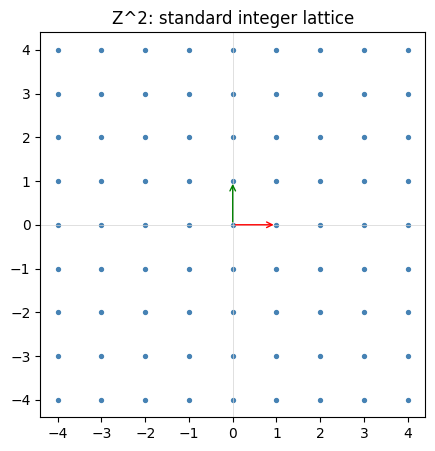

In [2]:
plot_lattice_2d(np.eye(2), radius=4)
plt.title('Z^2: standard integer lattice')
plt.show()

## Good vs. bad bases

The **same lattice** can be described by different bases. A *good* basis has short, nearly orthogonal vectors. A *bad* basis has long, skewed vectors that are nearly parallel. Both span exactly the same set of lattice points — but algorithmically, a good basis makes CVP easy and a bad basis makes it hard. Much of lattice cryptanalysis is about turning a bad basis into a good one (lattice reduction, e.g. LLL and BKZ).

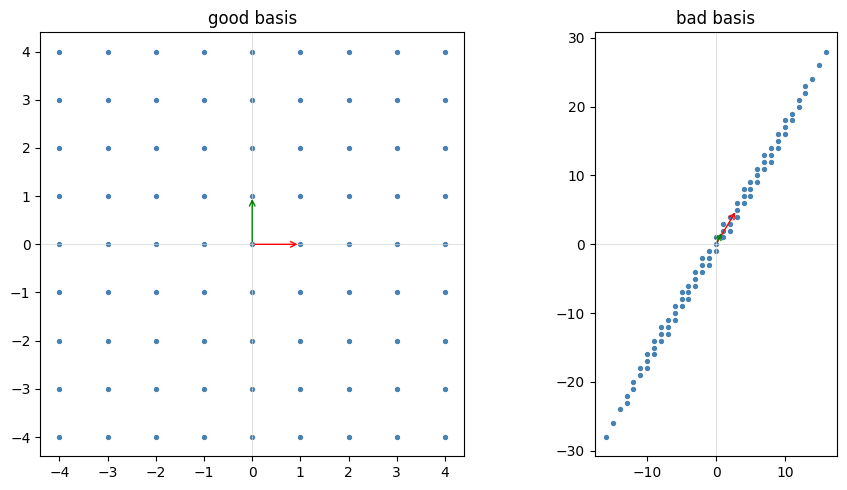

In [3]:
good, bad = good_vs_bad_basis()
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_lattice_2d(good, 4, ax=axes[0])
axes[0].set_title('good basis')
plot_lattice_2d(bad, 4, ax=axes[1])
axes[1].set_title('bad basis')
plt.tight_layout()
plt.show()

## The two hard problems

**Shortest Vector Problem (SVP):** given a basis of $L$, find a nonzero lattice vector of minimum Euclidean length.

**Closest Vector Problem (CVP):** given a basis of $L$ and a target point $t \notin L$, find the lattice vector closest to $t$.

Both problems are easy in 2-D (you can just look). In high dimensions, both are **NP-hard in the worst case**, and the best known algorithms — classical *and* quantum — take time exponential in the dimension.

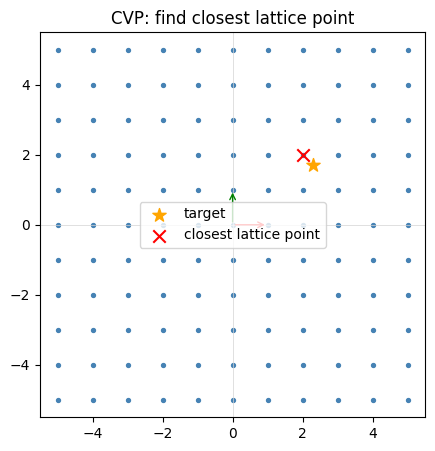

In [4]:
target = np.array([2.3, 1.7])
plot_lattice_2d(good, 5, target=target)
plt.title('CVP: find closest lattice point')
plt.show()

## Why quantum-hard?

Shor's algorithm breaks **integer factorization** and the **discrete logarithm** in polynomial time on a quantum computer — that kills RSA, DH, and ECC.

But no known polynomial-time quantum algorithm solves approximate SVP or CVP in high dimensions. The best quantum speedups are only *polynomial* improvements over classical exponential-time algorithms (e.g. Grover-style).

**LWE**, which we meet in the next notebook, *reduces* to a CVP-like problem — so breaking LWE would break hard lattice problems. That's the foundation of modern PQC (ML-KEM, ML-DSA).

→ Next: `02_toy_lwe.ipynb`.